In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

df = pd.read_csv("/kaggle/input/datasets/mohamedaln/merged-moffitt-boundaries-cleaned-v2/merged_moffitt_boundaries_cleaned_v2.csv")
print(f"Total cells: {len(df)}")
print(f"Cell classes: {df['Cell_class'].nunique()}")
print(df["Cell_class"].value_counts())

Total cells: 32648
Cell classes: 15
Cell_class
Inhibitory       11330
Excitatory        5383
Astrocyte         4822
OD Mature 2       3229
Endothelial 1     2377
OD Immature 1     1298
Ependymal         1040
Microglia          886
Endothelial 3      800
OD Mature 1        535
Pericytes          344
Endothelial 2      332
OD Mature 4        180
OD Immature 2       59
OD Mature 3         33
Name: count, dtype: int64


In [41]:
# ==============================================================
# Chunk 2 – Parse boundary coordinates with stricter validation
# ==============================================================
# Some boundary strings contain corrupted entries (standalone '-',
# mismatched X/Y lengths, extreme outlier vertices).
# We parse carefully and validate each cell's polygon.
# ==============================================================

def parse_boundary(s):
    """Convert semicolon-separated string to NumPy array, skipping invalid entries."""
    if not isinstance(s, str):
        return np.array([])
    parts = s.split(';')
    vals = []
    for p in parts:
        p = p.strip()
        if p == '' or p == '-':
            continue
        try:
            vals.append(float(p))
        except ValueError:
            continue
    return np.array(vals)

df["bx"] = df["boundaryX"].apply(parse_boundary)
df["by"] = df["boundaryY"].apply(parse_boundary)

# ---- Strict validation ----
# 1. X and Y must have the same number of vertices
df["len_match"] = df["bx"].apply(len) == df["by"].apply(len)

# 2. Must have at least 3 vertices to form a polygon
df["enough_pts"] = df["bx"].apply(len) >= 3

# 3. Polygon should be compact — reject cells where the bounding box
#    of the polygon is unreasonably large (lines stretching across the plot).
#    Normal cells span ~10-100 units; corrupted ones span thousands.
def bbox_size(arr):
    if len(arr) < 2:
        return np.inf
    return arr.max() - arr.min()

df["bx_span"] = df["bx"].apply(bbox_size)
df["by_span"] = df["by"].apply(bbox_size)

# Keep only cells where polygon span is reasonable (< 500 units)
# Adjust this threshold if needed based on your data
MAX_SPAN = 200
# Check the distribution of polygon spans
print("X span stats:")
print(df[df["bx_span"] < 1000]["bx_span"].describe())
print("\nY span stats:")
print(df[df["by_span"] < 1000]["by_span"].describe())
valid = df["len_match"] & df["enough_pts"] & (df["bx_span"] < MAX_SPAN) & (df["by_span"] < MAX_SPAN)

print(f"Total cells: {len(df)}")
print(f"Valid cells: {valid.sum()}")
print(f"Rejected (mismatched lengths): {(~df['len_match']).sum()}")
print(f"Rejected (too few points): {(~df['enough_pts']).sum()}")
print(f"Rejected (oversized bbox): {((df['bx_span'] >= MAX_SPAN) | (df['by_span'] >= MAX_SPAN)).sum()}")

df = df[valid].reset_index(drop=True)

# Clean up temp columns
df = df.drop(columns=["len_match", "enough_pts", "bx_span", "by_span"])

print(f"\nFinal valid cells: {len(df)}")
print("Boundaries parsed and validated successfully.")

X span stats:
count    32353.000000
mean        10.831396
std          4.079927
min          0.545000
25%          7.942000
50%         10.355000
75%         13.298000
max         39.894000
Name: bx_span, dtype: float64

Y span stats:
count    32390.000000
mean        10.902725
std         14.504260
min          1.199000
25%          7.739000
50%         10.137000
75%         12.753000
max        725.374000
Name: by_span, dtype: float64
Total cells: 32648
Valid cells: 31992
Rejected (mismatched lengths): 259
Rejected (too few points): 0
Rejected (oversized bbox): 433

Final valid cells: 31992
Boundaries parsed and validated successfully.


In [42]:
print(df["Bregma"].value_counts())

Bregma
-0.09    5545
 0.21    4781
-0.24    3874
 0.11    3841
-0.19    3783
 0.06    3782
-0.14    1136
 0.01    1135
-0.29    1063
 0.16    1040
-0.04    1020
 0.26     992
Name: count, dtype: int64


Plotting all cells: 100%|██████████| 31992/31992 [00:52<00:00, 615.23it/s]


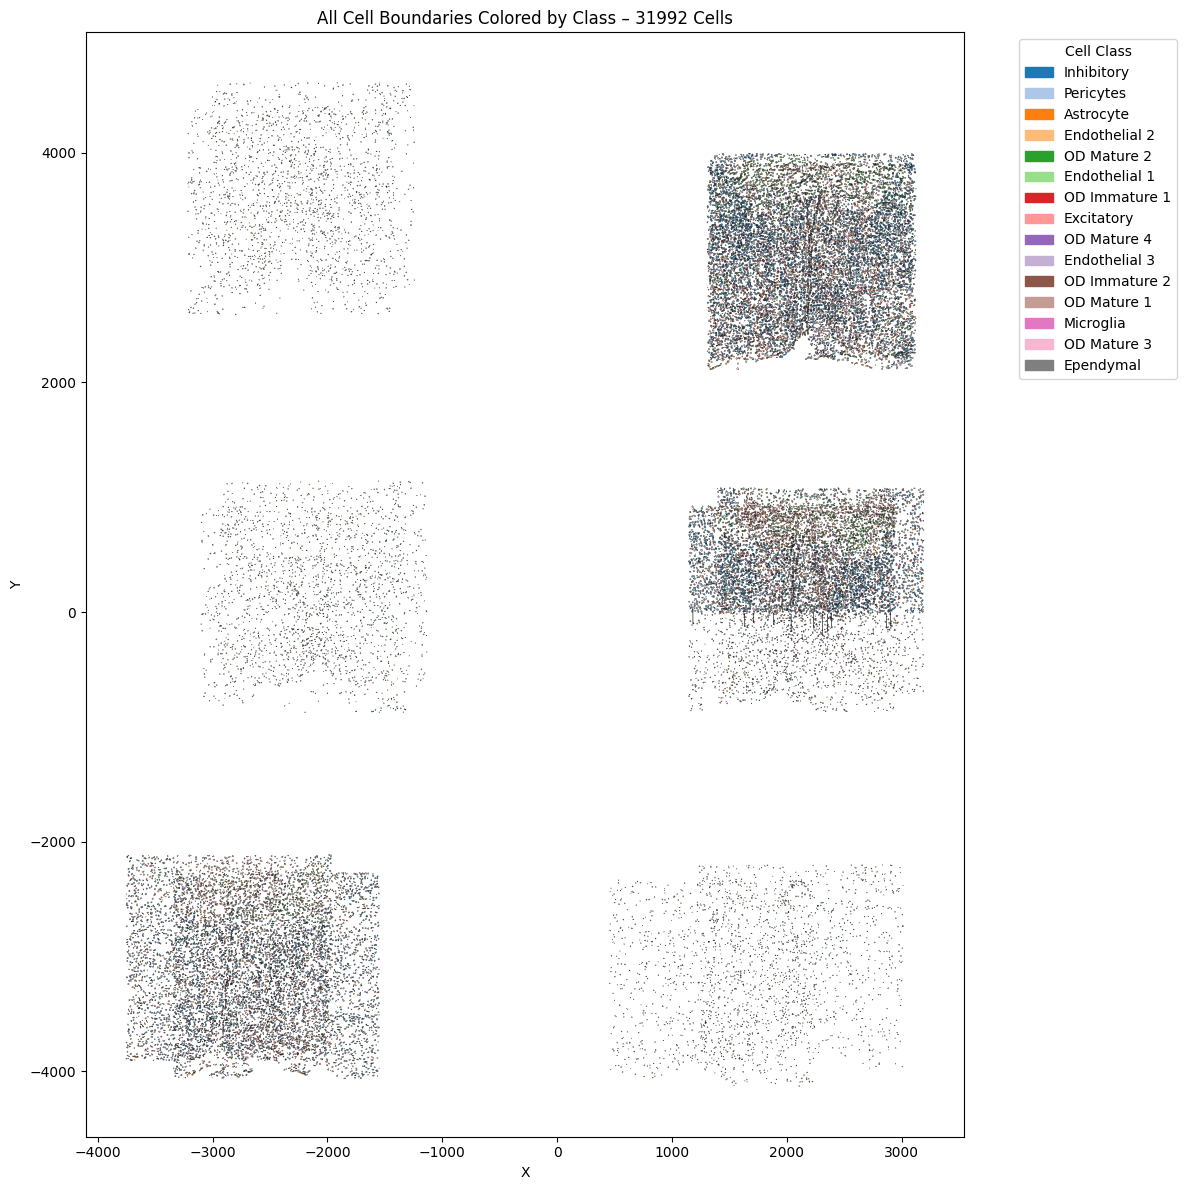

In [43]:
# ==============================================================
# Chunk 3 – Plot ALL cell boundaries colored by Cell_class
# ==============================================================
# Each cell's polygon is rendered using plt.fill() with its parsed
# boundary coordinates. Colors are assigned per cell class using
# Matplotlib's tab20 colormap (supports up to 20 distinct colors).
# ==============================================================

# Get unique cell classes and assign a color to each
unique_classes = df["Cell_class"].unique()
cmap = plt.colormaps['tab20']
color_dict = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}

# Create full-extent plot of all cell boundaries
plt.figure(figsize=(14, 12))

for _, row in tqdm(df.iterrows(), total=len(df), desc="Plotting all cells", colour="green"):
    bx = row["bx"]
    by = row["by"]

    # Skip cells where X and Y arrays have mismatched lengths or too few points
    if len(bx) != len(by) or len(bx) < 3:
        continue

    # Draw filled polygon with thin black edges and 70% opacity
    plt.fill(bx, by, color=color_dict[row["Cell_class"]],
             linewidth=0.3, edgecolor='black', alpha=0.7)

# Build legend with one entry per cell class
handles = [mpatches.Patch(color=color_dict[cls], label=cls) for cls in unique_classes]
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.25, 1.0), title="Cell Class")

plt.title(f"All Cell Boundaries Colored by Class – {len(df)} Cells")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect("equal")  # Preserve spatial proportions
plt.tight_layout()
plt.show()

Plotting Bregma = -0.09, cells = 5545


Plotting: 100%|██████████| 5545/5545 [00:09<00:00, 587.76it/s]


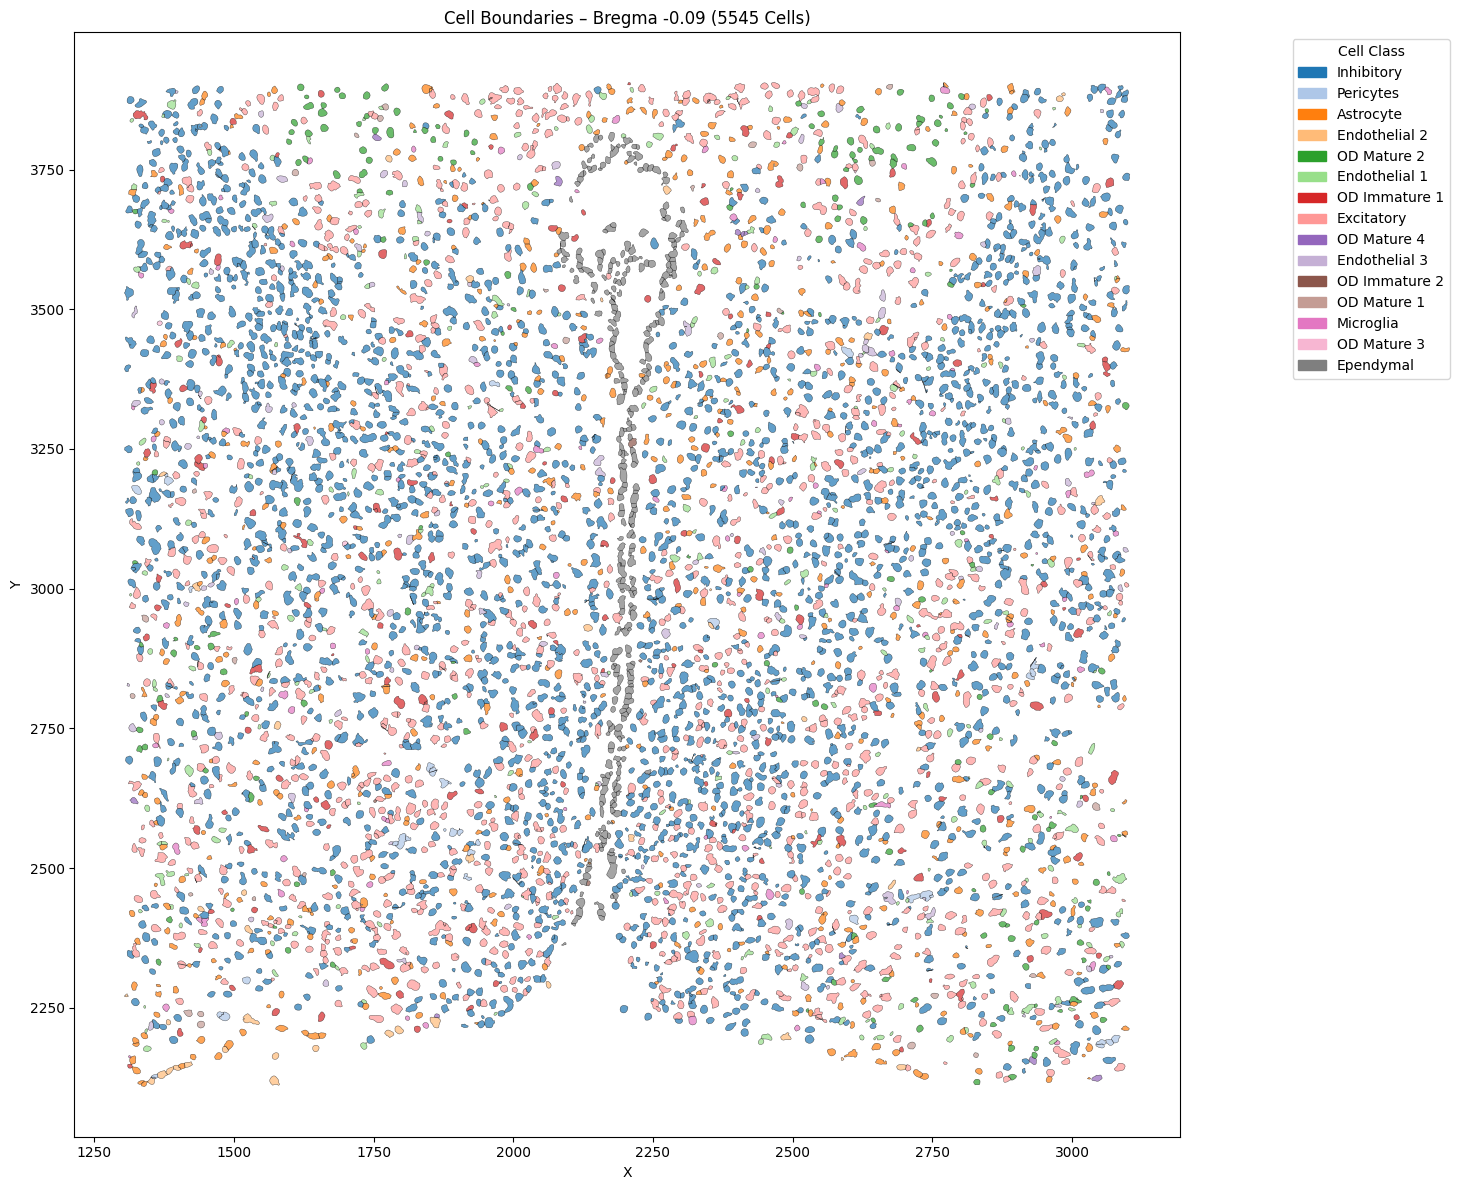

In [44]:
# ==============================================================
# Chunk 4 – Plot cells for a SINGLE Bregma slice (cleaner view)
# ==============================================================
bregma_val = df["Bregma"].value_counts().index[0] # as we change the index from 0-11, the plot differs
df_slice = df[df["Bregma"] == bregma_val].reset_index(drop=True)
print(f"Plotting Bregma = {bregma_val}, cells = {len(df_slice)}")

unique_classes = df["Cell_class"].unique()
cmap = plt.colormaps['tab20']
color_dict = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}

plt.figure(figsize=(14, 12))
for _, row in tqdm(df_slice.iterrows(), total=len(df_slice), desc="Plotting", colour="green"):
    bx = row["bx"]
    by = row["by"]
    if len(bx) != len(by) or len(bx) < 3:
        continue
    plt.fill(bx, by, color=color_dict[row["Cell_class"]],
             linewidth=0.3, edgecolor='black', alpha=0.7)

handles = [mpatches.Patch(color=color_dict[cls], label=cls) for cls in unique_classes]
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.25, 1.0), title="Cell Class")
plt.title(f"Cell Boundaries – Bregma {bregma_val} ({len(df_slice)} Cells)")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

In [45]:
# ==============================================================
# Chunk 5 – Check coordinate range for choosing zoom windows
# ==============================================================
# Before creating zoomed views, we need to know the spatial extent
# of the data so we can pick meaningful rectangular regions to zoom into.
# ==============================================================

print(f"X range: {df['Centroid_X'].min():.0f} to {df['Centroid_X'].max():.0f}")
print(f"Y range: {df['Centroid_Y'].min():.0f} to {df['Centroid_Y'].max():.0f}")

X range: -3751 to 3192
Y range: -4127 to 4608


Plotting zoom: 100%|██████████| 741/741 [00:01<00:00, 579.47it/s]


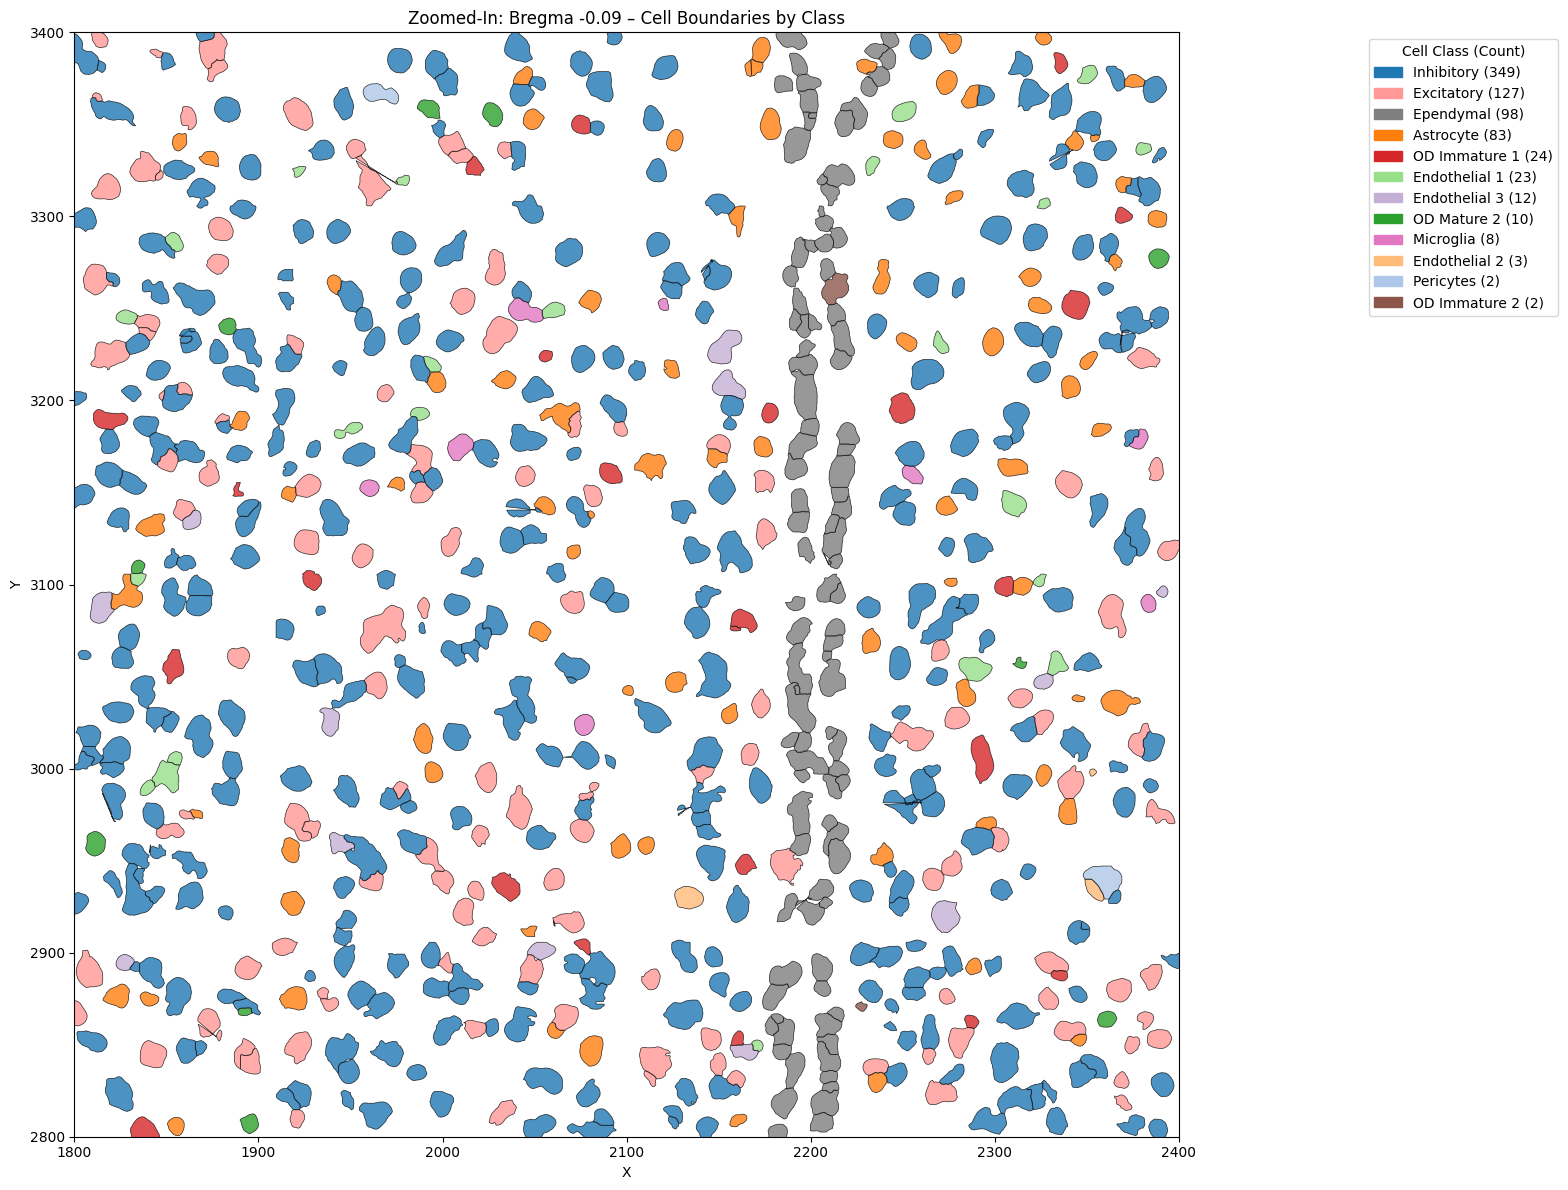

In [46]:
# ==============================================================
# Chunk 6 – Zoomed-In view of Bregma -0.09 with per-class counts
# ==============================================================
x_start, x_end = 1800, 2400
y_start, y_end = 2800, 3400

zoom_df = df_slice[
    (df_slice["Centroid_X"] >= x_start) & (df_slice["Centroid_X"] <= x_end) &
    (df_slice["Centroid_Y"] >= y_start) & (df_slice["Centroid_Y"] <= y_end)
]
zoom_counts = zoom_df["Cell_class"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 12))
for _, row in tqdm(zoom_df.iterrows(), total=len(zoom_df), desc="Plotting zoom", colour="green"):
    bx = row["bx"]
    by = row["by"]
    if len(bx) != len(by) or len(bx) < 3:
        continue
    plt.fill(bx, by, color=color_dict[row["Cell_class"]],
             linewidth=0.5, edgecolor='black', alpha=0.8)

handles = [mpatches.Patch(color=color_dict[cls], label=f"{cls} ({zoom_counts[cls]})")
           for cls in zoom_counts.index]
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.35, 1.0), title="Cell Class (Count)")
plt.title(f"Zoomed-In: Bregma {bregma_val} – Cell Boundaries by Class")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

Plotting zoom 2: 100%|██████████| 692/692 [00:01<00:00, 576.32it/s]


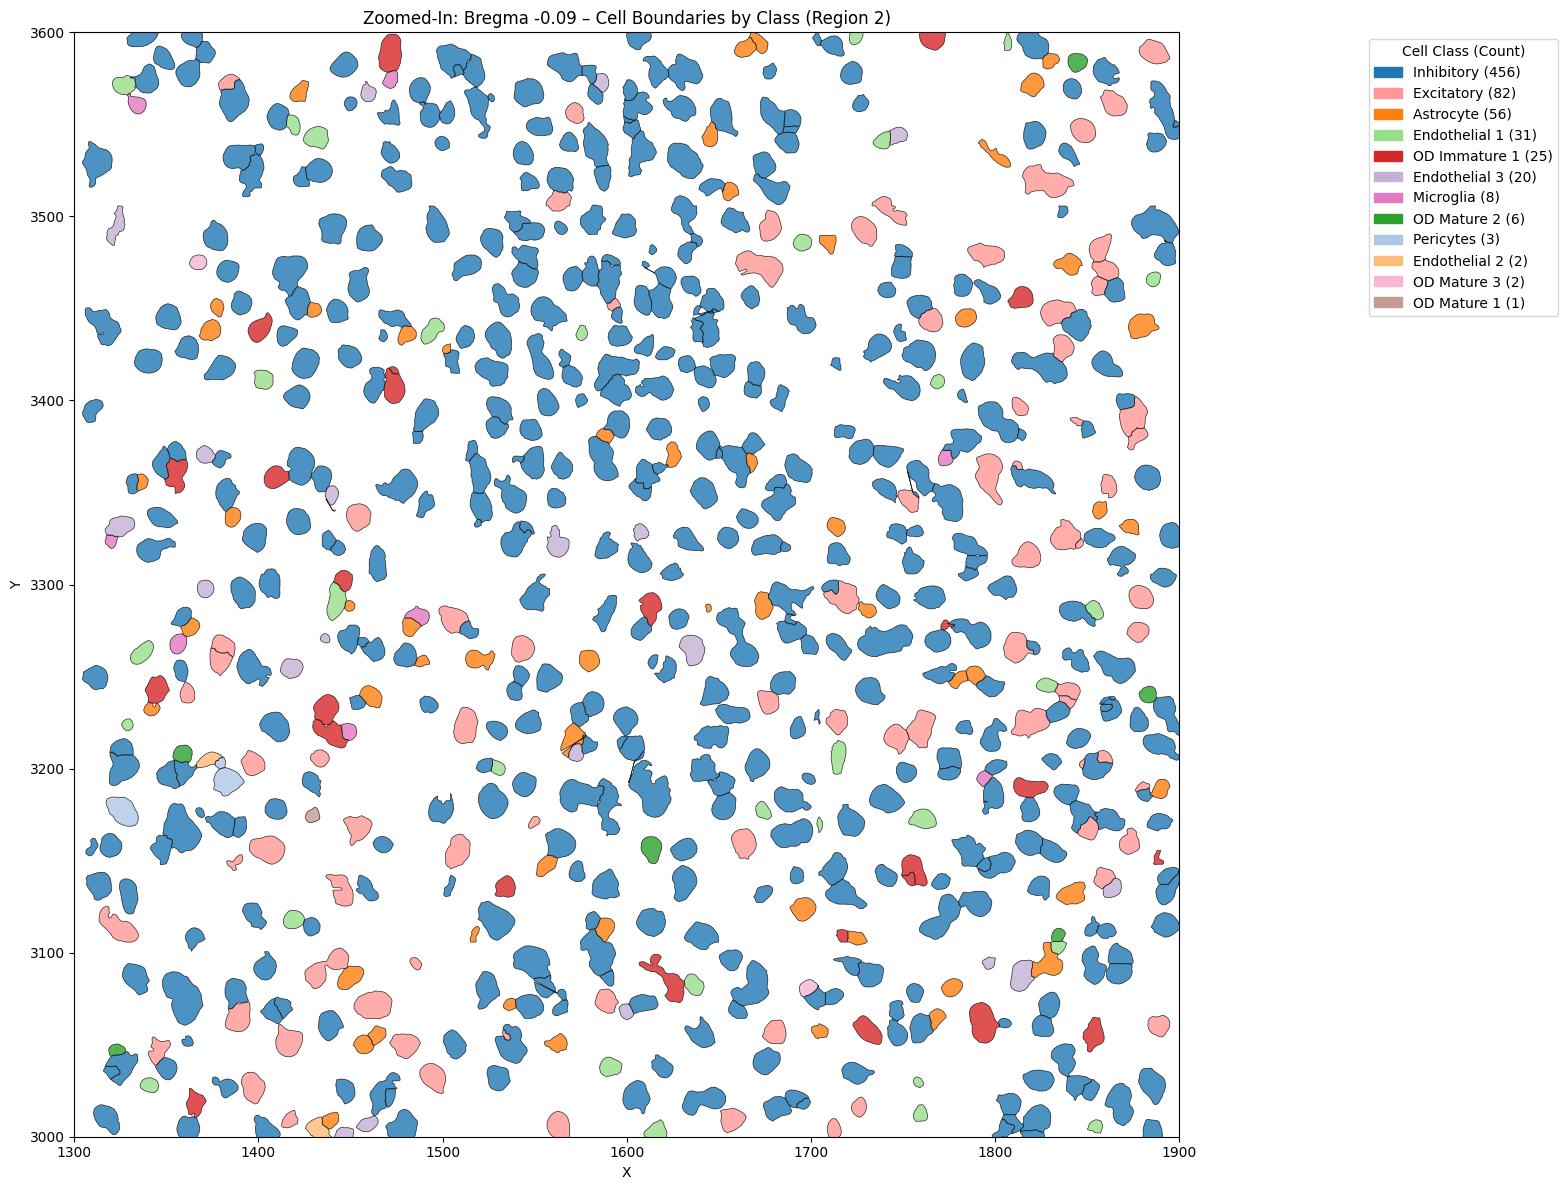

In [47]:
# ==============================================================
# Chunk 7 – Second zoomed view (different region, away from ventricle)
# ==============================================================
x_start, x_end = 1300, 1900
y_start, y_end = 3000, 3600

zoom_df2 = df_slice[
    (df_slice["Centroid_X"] >= x_start) & (df_slice["Centroid_X"] <= x_end) &
    (df_slice["Centroid_Y"] >= y_start) & (df_slice["Centroid_Y"] <= y_end)
]
zoom_counts2 = zoom_df2["Cell_class"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 12))
for _, row in tqdm(zoom_df2.iterrows(), total=len(zoom_df2), desc="Plotting zoom 2", colour="green"):
    bx = row["bx"]
    by = row["by"]
    if len(bx) != len(by) or len(bx) < 3:
        continue
    plt.fill(bx, by, color=color_dict[row["Cell_class"]],
             linewidth=0.5, edgecolor='black', alpha=0.8)

handles = [mpatches.Patch(color=color_dict[cls], label=f"{cls} ({zoom_counts2[cls]})")
           for cls in zoom_counts2.index]
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.35, 1.0), title="Cell Class (Count)")
plt.title(f"Zoomed-In: Bregma {bregma_val} – Cell Boundaries by Class (Region 2)")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

Plotting Bregmas: 100%|██████████| 12/12 [00:51<00:00,  4.26s/it]


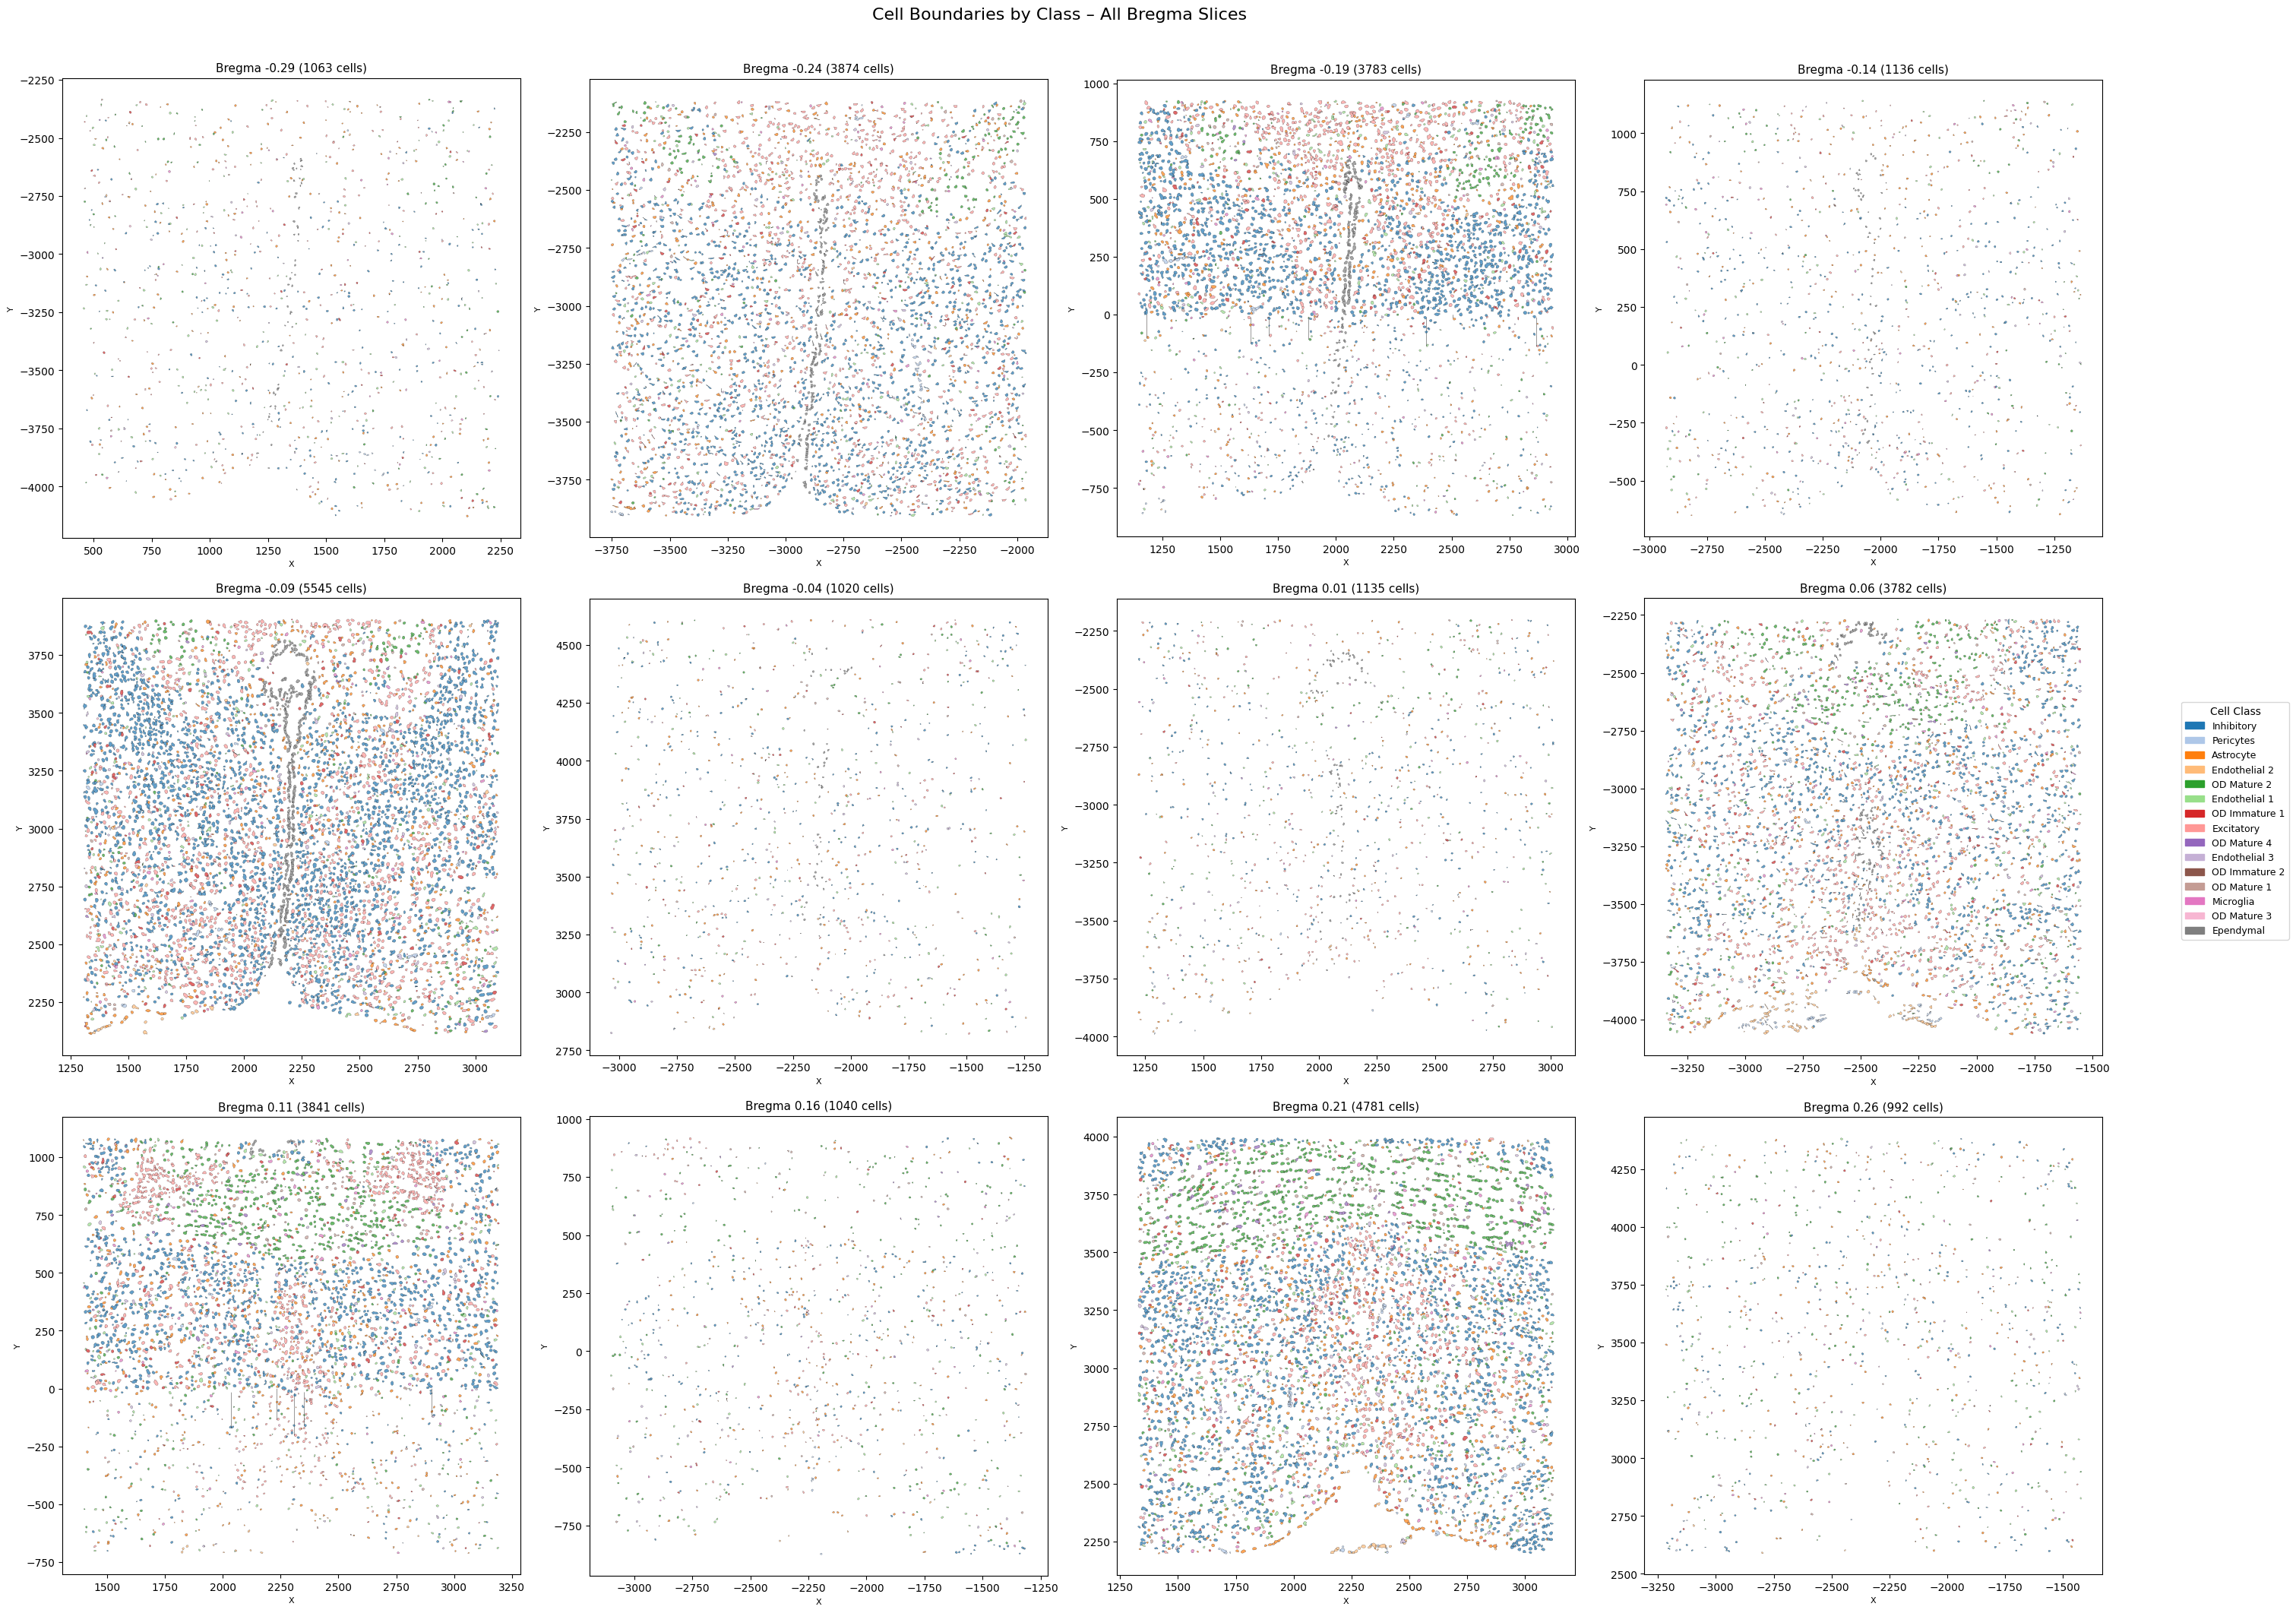

In [48]:
# ==============================================================
# Chunk 8 – Plot ALL Bregma slices in a single figure (subplot grid)
# ==============================================================
# Each subplot shows one Bregma slice with cells colored by class.
# Arranged in a 3x4 grid (12 Bregma values).
# ==============================================================

unique_classes = df["Cell_class"].unique()
cmap = plt.colormaps['tab20']
color_dict = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}

# Sort Bregma values for consistent ordering
bregma_vals = sorted(df["Bregma"].unique())

fig, axes = plt.subplots(3, 4, figsize=(28, 21))
axes = axes.flatten()

for idx, bregma_val in enumerate(tqdm(bregma_vals, desc="Plotting Bregmas")):
    ax = axes[idx]
    df_slice = df[df["Bregma"] == bregma_val]

    for _, row in df_slice.iterrows():
        bx = row["bx"]
        by = row["by"]
        if len(bx) != len(by) or len(bx) < 3:
            continue
        ax.fill(bx, by, color=color_dict[row["Cell_class"]],
                linewidth=0.2, edgecolor='black', alpha=0.7)

    ax.set_title(f"Bregma {bregma_val} ({len(df_slice)} cells)", fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlabel("X", fontsize=8)
    ax.set_ylabel("Y", fontsize=8)

# Shared legend
handles = [mpatches.Patch(color=color_dict[cls], label=cls) for cls in unique_classes]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.08, 0.5),
           title="Cell Class", fontsize=9, title_fontsize=10)

fig.suptitle("Cell Boundaries by Class – All Bregma Slices", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()